In [ ]:
import sys
sys.path.append('..')
from utils_activations import *
from utils import makefolder

rcpsize = 22
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
colors = plt.style.library['ggplot']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
markers = ['p','o','h','^','s','*']
_linestyles = ['-','--','dotted']
plot_id = 0


In [19]:
# Norm computation moved to compute_norms.py and snorms.sh.
# This notebook now reads saved results and produces plots only.


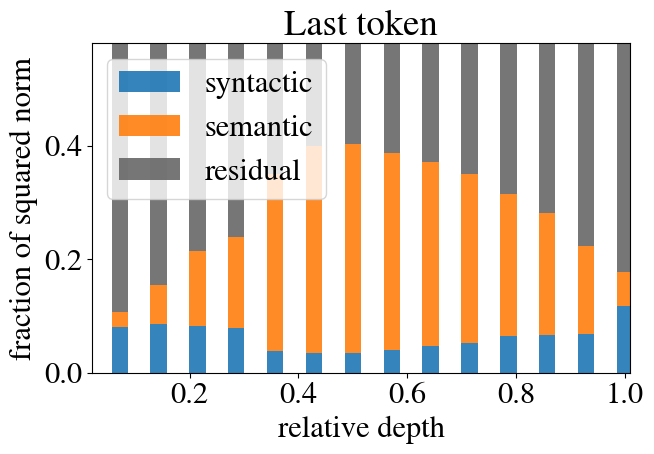

In [27]:
import os
import numpy as np

model_name = 'qwen7b'
data_var = 'sem'
avg_tokens_list = [0]
min_token_length = 3
n_tokens = 1
global_center_flag = 1

for avg_tokens in avg_tokens_list:
    load_n_tokens = min_token_length if avg_tokens == 1 else n_tokens
    resultsfolder = makefolder(base='../results/norms/syn-sem/',
                            model_name=model_name,
                            avg_tokens=avg_tokens,
                            min_token_length=min_token_length,
                            n_tokens=load_n_tokens,
                            global_center_flag=global_center_flag,
                            )
    npz_path = os.path.join(resultsfolder, "norms.npz")
    data = np.load(npz_path)

    layer_vals      = data["layer_vals"]
    rel_depths      = data["rel_depths"]
    syn_means       = data["syn_means"]
    sem_means       = data["sem_means"]
    residual_means  = data["residual_means"]
    cos_means       = data["cos_means"]
    cos_stds        = data["cos_stds"]

    # Plot
    fig, ax = plt.subplots(figsize=(7, 5))

    bar_width = 0.03  # adjust for [0, 1] x-axis
    n_layers = len(rel_depths)
    x = np.linspace(1/n_layers, 1, n_layers)


    ax.bar(x, syn_means, width=bar_width, color="#1f77b4", label="syntactic", alpha=0.9)
    ax.bar(x, sem_means, width=bar_width, bottom=syn_means, color="#ff7f0e", label="semantic", alpha=0.9)
    ax.bar(x, residual_means, width=bar_width, bottom=syn_means + sem_means, color="#676767", label="residual", alpha=0.9)

    ax.set_xticks(np.linspace(0, 1, 6))
    ax.set_xticklabels([f"{t:.1f}" for t in np.linspace(0, 1, 6)])
    ax.set_xlabel("relative depth", fontsize=rcpsize)
    ax.set_ylabel("fraction of squared norm", fontsize=rcpsize)

    # box = ax.get_position()
    # ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    # ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.legend(loc='upper left')
    ax.set_ylim(0, .58)
    ax.set_xlim(0.02,1.01)
    title = 'Last token' if n_tokens == 1 else ('Concatenation' if avg_tokens == 0 else 'Average')
    ax.set_title(title)
    plt.tight_layout()
    figs_folder = f'../results/figs/norms/n_tokens_{n_tokens}/'
    os.makedirs(figs_folder, exist_ok=True)
    # fig.savefig(figs_folder + f'{model_name}_syn_sem_norms_avg_{avg_tokens}.pdf')
    plt.show()


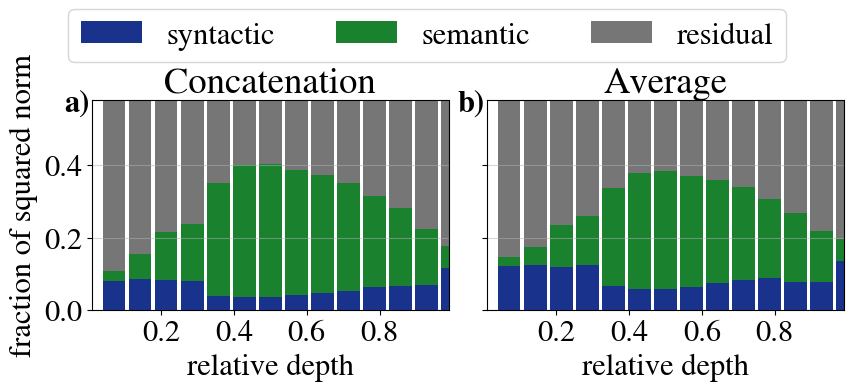

In [21]:
avg_tokens_list = [0, 1]

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

for i, avg_tokens in enumerate(avg_tokens_list):
    ax = axes[i]
    load_n_tokens = min_token_length if avg_tokens == 1 else n_tokens

    resultsfolder = makefolder(base='../results/norms/syn-sem/',
                            model_name=model_name,
                            avg_tokens=avg_tokens,
                            min_token_length=min_token_length,
                            n_tokens=load_n_tokens,
                            global_center_flag=global_center_flag,
                            )
    npz_path = os.path.join(resultsfolder, "norms.npz")
    data = np.load(npz_path)

    layer_vals      = data["layer_vals"]
    rel_depths      = data["rel_depths"]
    syn_means       = data["syn_means"]
    sem_means       = data["sem_means"]
    residual_means  = data["residual_means"]
    cos_means       = data["cos_means"]
    cos_stds        = data["cos_stds"]

    # --- your original x-axis logic ---
    bar_width = 0.062  # adjust for [0, 1] x-axis
    n_layers = len(rel_depths)
    x = np.linspace(1/n_layers, 1, n_layers)
    # -----------------------------------

    # keep half of the bars: take every second one (0,2,4,...)
    if model_name != 'qwen7b':
        idx = np.arange(n_layers)
        mask = (idx % 2 == 0)
        x = x[mask]
        syn_means = syn_means[mask]
        sem_means = sem_means[mask]
        residual_means = residual_means[mask]


    ax.bar(
        x, syn_means,
        width=bar_width,
        label="syntactic",
        alpha=0.9,
    )
    ax.bar(
        x, sem_means,
        width=bar_width,
        bottom=syn_means,
        label="semantic",
        alpha=0.9,
    )
    ax.bar(
        x, residual_means,
        width=bar_width,
        bottom=syn_means + sem_means,
        label="residual",
        alpha=0.9,
        color="#676767",
    )

    ax.set_xticks(np.linspace(0, 1, 6))
    ax.set_xticklabels([f"{t:.1f}" for t in np.linspace(0, 1, 6)])

    if i == 0:
        ax.set_ylabel("fraction of squared norm", fontsize=rcpsize)
    ax.set_xlabel("relative depth", fontsize=rcpsize)

    ax.set_ylim(0, 0.58)
    ax.set_xlim(0.01, .99)
    ax.grid(True, axis="y", alpha=0.5)

    title = 'Concatenation' if avg_tokens == 0 else 'Average'
    ax.set_title(title)

# Shared legend using handles from first axis
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',
    ncol=3,
    bbox_to_anchor=(0.5, 1.05),
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Add panel labels
panel_labels = ['a)', 'b)']
for i, label in enumerate(panel_labels):
    axes[i].text(
        -0.005, 1.05,      # x, y in axis coordinates
        label,
        transform=axes[i].transAxes,  # coordinates relative to the axes
        fontsize=rcpsize,
        fontweight='bold',
        va='top',
        ha='right'
    )

figs_folder = f'../results/figs/norms/n_tokens_{n_tokens}/'
os.makedirs(figs_folder, exist_ok=True)
if global_center_flag == 1:
  fig.savefig(os.path.join(figs_folder, f"{model_name}_syn_sem_norms_bars_both_half.pdf"))
plt.show()


/tmp/ipykernel_3700768/3630755276.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.savefig(os.path.join(figs_folder,
/home/acevedo/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


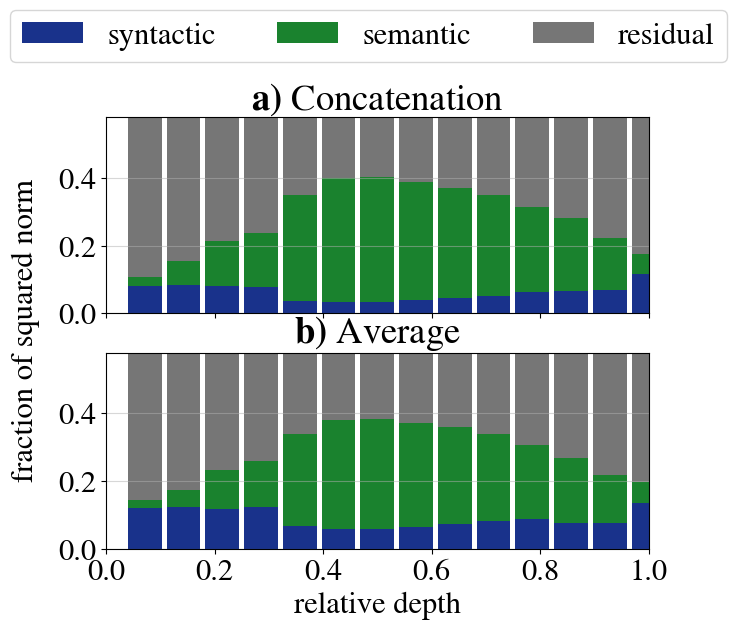

In [22]:
avg_tokens_list = [0, 1]

# Vertical stack + compact spacing
fig, axes = plt.subplots(
    2, 1,
    figsize=(7, 5.6),
    sharex=True,
    sharey=True,
    gridspec_kw={"hspace": 0.20}   # smaller = more compact
)

for i, avg_tokens in enumerate(avg_tokens_list):
    ax = axes[i]
    load_n_tokens = min_token_length if avg_tokens == 1 else n_tokens

    resultsfolder = makefolder(base='../results/norms/syn-sem/',
                            model_name=model_name,
                            avg_tokens=avg_tokens,
                            min_token_length=min_token_length,
                            n_tokens=load_n_tokens,
                            global_center_flag=global_center_flag,
                            )
    npz_path = os.path.join(resultsfolder, "norms.npz")
    data = np.load(npz_path)

    rel_depths      = data["rel_depths"]
    syn_means       = data["syn_means"]
    sem_means       = data["sem_means"]
    residual_means  = data["residual_means"]

    # --- your original x-axis logic ---
    bar_width = 0.062
    n_layers = len(rel_depths)
    x = np.linspace(1/n_layers, 1, n_layers)
    # -----------------------------------

    # keep half of the bars: take every second one (0,2,4,...)
    if model_name != 'qwen7b':
        idx = np.arange(n_layers)
        mask = (idx % 2 == 0)
        x = x[mask]
        syn_means = syn_means[mask]
        sem_means = sem_means[mask]
        residual_means = residual_means[mask]

    ax.bar(x, syn_means, width=bar_width, label="syntactic", alpha=0.9)
    ax.bar(x, sem_means, width=bar_width, bottom=syn_means, label="semantic", alpha=0.9)
    ax.bar(
        x, residual_means, width=bar_width, bottom=syn_means + sem_means,
        label="residual", alpha=0.9, color="#676767"
    )

    ax.set_xlim(0.01, 0.99)
    ax.set_ylim(0, 0.58)
    ax.grid(True, axis="y", alpha=0.5)

    if avg_tokens == 0:
        title = r'$\mathbf{a)}$ Concatenation'
    else:
        title = r'$\mathbf{b)}$ Average'
    ax.set_title(title)


# Only bottom axis gets the x-axis labels for compactness
axes[-1].set_xticks(np.linspace(0, 1, 6))
axes[-1].set_xticklabels([f"{t:.1f}" for t in np.linspace(0, 1, 6)])
axes[-1].set_xlabel("relative depth", fontsize=rcpsize)

# One shared big y-label
fig.supylabel("fraction of squared norm", fontsize=rcpsize, x=-0.01)

# Shared legend using handles from first axis
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',
    ncol=3,
    bbox_to_anchor=(0.5, 1.1),
)

# # Leave room for the outside legend + tighten margins
# fig.subplots_adjust(left=0.10, right=0.82, top=0.95, bottom=0.10)

figs_folder = f'../results/figs/norms/n_tokens_{n_tokens}/'
os.makedirs(figs_folder, exist_ok=True)
if global_center_flag == 1:
    fig.savefig(os.path.join(figs_folder, 
                             f"{model_name}_syn_sem_norms_bars_both_half_vertical.pdf"),
                             bbox_inches='tight')

plt.show()


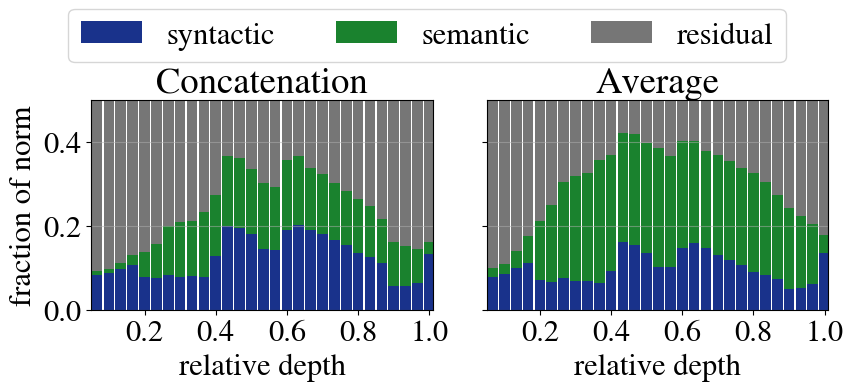

In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt

model_name = 'deepseek'
data_var = 'sem'
avg_tokens_list = [0, 1]
min_token_length = 3
n_tokens = min_token_length
global_center_flag = 1

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

for i, avg_tokens in enumerate(avg_tokens_list):
    ax = axes[i]
    load_n_tokens = min_token_length if avg_tokens == 1 else n_tokens

    resultsfolder = makefolder(base='../results/norms/syn-sem/',
                            model_name=model_name,
                            avg_tokens=avg_tokens,
                            min_token_length=min_token_length,
                            n_tokens=load_n_tokens,
                            global_center_flag=global_center_flag,
                            )
    npz_path = os.path.join(resultsfolder, "norms.npz")
    data = np.load(npz_path)

    layer_vals      = data["layer_vals"]
    rel_depths      = data["rel_depths"]
    syn_means       = data["syn_means"]
    sem_means       = data["sem_means"]
    residual_means  = data["residual_means"]
    cos_means       = data["cos_means"]
    cos_stds        = data["cos_stds"]

    # --- your original x-axis logic ---
    bar_width = 0.03  # adjust for [0, 1] x-axis
    n_layers = len(rel_depths)
    x = np.linspace(1/n_layers, 1, n_layers)
    # -----------------------------------

    ax.bar(x, syn_means,
           width=bar_width,
           label="syntactic",
           alpha=0.9)
    ax.bar(x, sem_means,
           width=bar_width,
           bottom=syn_means,
           label="semantic",
           alpha=0.9)
    ax.bar(x, residual_means,
           width=bar_width,
           bottom=syn_means + sem_means,
           label="residual",
           alpha=0.9,
            color="#676767",)

    ax.set_xticks(np.linspace(0, 1, 6))
    ax.set_xticklabels([f"{t:.1f}" for t in np.linspace(0, 1, 6)])

    if i == 0:
        ax.set_ylabel("fraction of norm", fontsize=rcpsize)
    ax.set_xlabel("relative depth", fontsize=rcpsize)

    ax.set_ylim(0, 0.5)
    ax.set_xlim(0.05,1.01)
    ax.grid(True, axis="y", alpha=0.5)

    title = 'Concatenation' if avg_tokens == 0 else 'Average'
    ax.set_title(title)

# Shared legend using handles from first axis
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='upper center',
           ncol=3,
           bbox_to_anchor=(0.5, 1.05))

plt.tight_layout(rect=[0, 0, 1, 0.95])

figs_folder = f'../results/figs/norms/n_tokens_{n_tokens}/'
os.makedirs(figs_folder, exist_ok=True)
fig.savefig(os.path.join(figs_folder, f"{model_name}_syn_sem_norms_bars_both.pdf"))
plt.show()


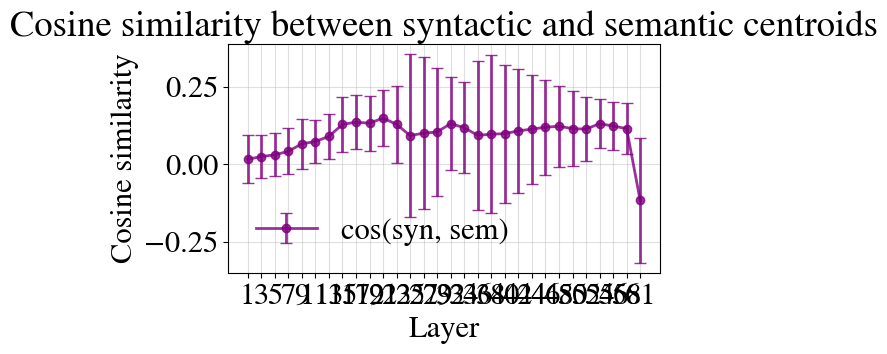

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(layer_vals))

ax.errorbar(
    x, cos_means, yerr=cos_stds, 
    fmt='-o', capsize=4, lw=2,
    color='purple', alpha=0.8, 
    label='cos(syn, sem)'
)

ax.set_xticks(x)
ax.set_xticklabels(layer_vals)
ax.set_xlabel("Layer")
ax.set_ylabel("Cosine similarity")
ax.set_title("Cosine similarity between syntactic and semantic centroids")
ax.legend(frameon=False)
ax.grid(alpha=0.4)

# ax.set_ylim(-.05,1.05)

plt.tight_layout()
plt.show()

In [25]:
# Centroid-level diagnostics that depended on in-notebook computation were removed.
# Recompute those quantities from saved artifacts or from compute_norms.py if needed.
